<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/supervised_learning/computer_vision/intel_image_scene_classification/project_intel_image_scene_classification_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CNN Model with Evaluation Strategy

Dataset: Intel Image Classification Dataset (Natural Scenes)

In [2]:
!pip install kaggle

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [4]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:01<00:00, 223MB/s]



In [5]:
!unzip intel-image-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jp

Import Libraries

In [6]:
# ============================================================
# PRODUCTION-LEVEL CNN MODEL
# Intel Natural Scene Classification
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

DATA PATHS

In [7]:
train_dir = "/content/seg_train/seg_train"
test_dir  = "/content/seg_test/seg_test"

IMG_SIZE = 224
BATCH_SIZE = 32

DATA AUGMENTATION

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.20,
    height_shift_range=0.20,

    shear_range=0.15,
    horizontal_flip=True,

    validation_split=0.20
)

# ============================================================
# TEST DATA
# ============================================================

test_datagen = ImageDataGenerator(
    rescale=1./255
)

DATA LOADING

In [9]:
# ============================================================
# TRAIN GENERATOR
# ============================================================

train_generator = train_datagen.flow_from_directory(
    train_dir,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'
)

# ============================================================
# VALIDATION GENERATOR
# ============================================================

val_generator = train_datagen.flow_from_directory(
    train_dir,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation'
)

# ============================================================
# TEST GENERATOR
# ============================================================

test_generator = test_datagen.flow_from_directory(
    test_dir,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


LOAD PRETRAINED MODEL

In [10]:
# ============================================================
# LOAD EFFICIENTNETB0
# ============================================================

base_model = EfficientNetB0(
    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3)
)

# Freeze base layers

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


BUILD PRODUCTION MODEL

In [11]:
# ============================================================
# CUSTOM CLASSIFICATION HEAD
# ============================================================

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(
    512,
    activation='relu'
)(x)

x = Dropout(0.40)(x)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.30)(x)

output_layer = Dense(
    6,
    activation='softmax'
)(x)

# ============================================================
# FINAL MODEL
# ============================================================

model = Model(
    inputs=base_model.input,
    outputs=output_layer
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,843,433 (18.48 MB)

 Trainable params: 791,302 (3.02 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

COMPILE MODEL

In [12]:
# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

CALLBACKS

In [13]:
# ============================================================
# CALLBACKS
# ============================================================

early_stopping = EarlyStopping(
    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',

    factor=0.2,

    patience=3,

    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",

    monitor='val_accuracy',

    save_best_only=True,

    verbose=1
)

TRAIN MODEL

In [14]:
# ============================================================
# TRAIN MODEL
# ============================================================

history = model.fit(
    train_generator,

    validation_data=val_generator,

    epochs=20,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.1890 - loss: 2.0215
Epoch 1: val_accuracy improved from None to 0.19650, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 238s 591ms/step - accuracy: 0.2037 - loss: 1.8880 - val_accuracy: 0.1965 - val_loss: 1.7765 - learning_rate: 0.0010
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.2310 - loss: 1.7287
Epoch 2: val_accuracy improved from 0.19650 to 0.21969, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 172s 489ms/step - accuracy: 0.2305 - loss: 1.7175 - val_accuracy: 0.2197 - val_loss: 1.7120 - learning_rate: 0.0010
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.2541 - loss: 1.6834
Epoch 3: val_accuracy improved from 0.21969 to 0.22575, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
351/351 ━━━━━━━━━━━━━━━━━━

PLOT ACCURACY

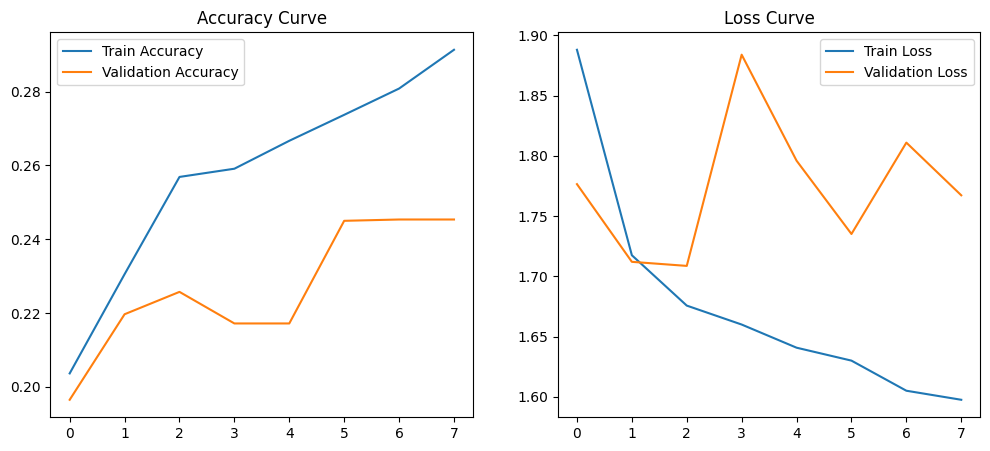

In [15]:
# ============================================================
# PLOT TRAINING HISTORY
# ============================================================

plt.figure(figsize=(12, 5))

# Accuracy

plt.subplot(1, 2, 1)

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Accuracy Curve")

plt.legend()

# Loss

plt.subplot(1, 2, 2)

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Loss Curve")

plt.legend()

plt.show()

MODEL EVALUATION

In [16]:
# ============================================================
# EVALUATE MODEL
# ============================================================

test_loss, test_accuracy = model.evaluate(
    test_generator
)

print(f"\nTest Accuracy: {test_accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.2810 - loss: 1.5617

Test Accuracy: 0.2810


PREDICTIONS

In [17]:
# ============================================================
# PREDICTIONS
# ============================================================

predictions = model.predict(
    test_generator
)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = test_generator.classes

94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step


CLASSIFICATION REPORT

In [18]:

class_names = list(
    test_generator.class_indices.keys()
)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   buildings       0.00      0.00      0.00       437
      forest       0.39      0.52      0.44       474
     glacier       0.17      0.08      0.11       553
    mountain       0.26      0.92      0.40       525
         sea       0.00      0.00      0.00       510
      street       0.29      0.14      0.19       501

    accuracy                           0.28      3000
   macro avg       0.19      0.28      0.19      3000
weighted avg       0.19      0.28      0.19      3000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


CONFUSION MATRIX

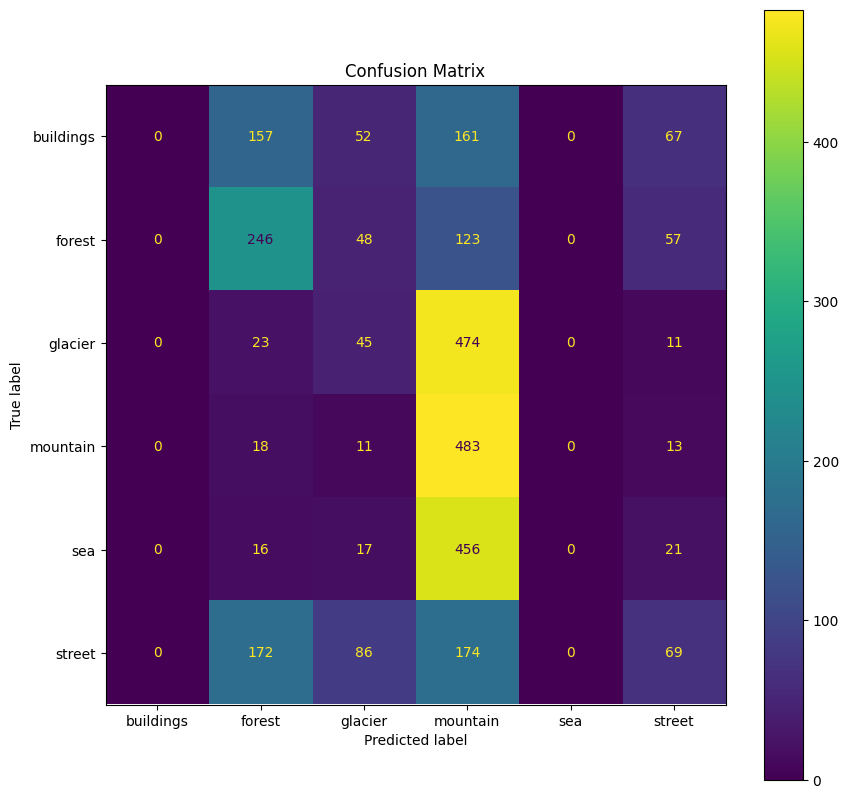

In [19]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(ax=ax)

plt.title("Confusion Matrix")

plt.show()

FINE TUNING (ADVANCED)

In [20]:
# ============================================================
# UNFREEZE TOP LAYERS
# ============================================================

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

RECOMPILE

In [21]:
# ============================================================
# RECOMPILE WITH LOWER LR
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

FINE-TUNE TRAINING

In [22]:
# ============================================================
# FINE-TUNING
# ============================================================

fine_tune_history = model.fit(
    train_generator,

    validation_data=val_generator,

    epochs=10,

    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 243s 593ms/step - accuracy: 0.2145 - loss: 1.7904 - val_accuracy: 0.1790 - val_loss: 2.0865 - learning_rate: 1.0000e-05
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 176s 503ms/step - accuracy: 0.2455 - loss: 1.6877 - val_accuracy: 0.1883 - val_loss: 1.8158 - learning_rate: 1.0000e-05
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.2541 - loss: 1.6715
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
351/351 ━━━━━━━━━━━━━━━━━━━━ 179s 509ms/step - accuracy: 0.2592 - loss: 1.6628 - val_accuracy: 0.1951 - val_loss: 1.7618 - learning_rate: 1.0000e-05
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 182s 518ms/step - accuracy: 0.2708 - loss: 1.6413 - val_accuracy: 0.1901 - val_loss: 1.9039 - learning_rate: 2.0000e-06
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 177s 504ms/step - accuracy: 0.2726 - loss: 1.6356 - val_accuracy: 0.1912 - val_loss: 1.9426 - learning_rate: 2.0000e-06
